# Linear regression

files needed = 'sleep75.dta', 'smoke.csv', 'broadband_size.xlsx', 'Card1995.dta'

This notebook introduces us to the statsmodels package [(docs)](https://devdocs.io/statsmodels/), which provides functions for formulating and estimating statistical models. This notebook will not address the models, per se, but will focus on how to put econometrics to work in python. It will then transition us to the topic of causality and econometric identification of causal effects.

Many of you have used STATA before. STATA is a great package for econometrics. Python can do most of what STATA can do, but STATA will have more specialized routines available. As python's popularity grows, the kinds of models you can estimate in it will grow as well.    

If STATA is your thing, this [page](http://rlhick.people.wm.edu/posts/comparing-stata-and-ipython-commands-for-ols-models.html) on Rob Hicks' website is a nice STATA-to-python concordance.  

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
# The new packages...
import statsmodels.api as sm           # provides statistical models like ols, gmm, anova, etc...
import statsmodels.formula.api as smf  # provides a way to directly spec models from formulas

os.chdir('/Users/jackson/Documents/ECON570')

In [17]:
# Use pandas read_stata method to get the stata formatted data file into a DataFrame.
sleep = pd.read_stata('data/sleep75.dta')

# Take a look...so clean!
sleep.head()

,age,black,case,clerical,construc,educ,earns74,gdhlth,inlf,leis1,...,spwrk75,totwrk,union,worknrm,workscnd,exper,yngkid,yrsmarr,hrwage,agesq
0,32.0,0.0,1.0,0.0,0.0,12.0,0.0,0.0,1.0,3529.0,...,0.0,3438.0,0.0,3438.0,0.0,14.0,0.0,13.0,7.070004,1024.0
1,31.0,0.0,2.0,0.0,0.0,14.0,9500.0,1.0,1.0,2140.0,...,0.0,5020.0,0.0,5020.0,0.0,11.0,0.0,0.0,1.429999,961.0
2,44.0,0.0,3.0,0.0,0.0,17.0,42500.0,1.0,1.0,4595.0,...,1.0,2815.0,0.0,2815.0,0.0,21.0,0.0,0.0,20.530001,1936.0
3,30.0,0.0,4.0,0.0,0.0,12.0,42500.0,1.0,1.0,3211.0,...,1.0,3786.0,0.0,3786.0,0.0,12.0,0.0,12.0,9.619998,900.0
4,64.0,0.0,5.0,0.0,0.0,14.0,2500.0,1.0,1.0,4052.0,...,1.0,2580.0,0.0,2580.0,0.0,44.0,0.0,33.0,2.750000,4096.0


In [18]:
sleep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 706 entries, 0 to 705
Data columns (total 34 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       706 non-null    float32
 1   black     706 non-null    float32
 2   case      706 non-null    float32
 3   clerical  706 non-null    float32
 4   construc  706 non-null    float32
 5   educ      706 non-null    float32
 6   earns74   706 non-null    float32
 7   gdhlth    706 non-null    float32
 8   inlf      706 non-null    float32
 9   leis1     706 non-null    float32
 10  leis2     706 non-null    float32
 11  leis3     706 non-null    float32
 12  smsa      706 non-null    float32
 13  lhrwage   532 non-null    float32
 14  lothinc   706 non-null    float32
 15  male      706 non-null    float32
 16  marr      706 non-null    float32
 17  prot      706 non-null    float32
 18  rlxall    706 non-null    float32
 19  selfe     706 non-null    float32
 20  sleep     706 non-null    float3

### Directly specifying and estimating models with the formula.api

The `statsmodels` package provides us with a formulaic syntax for defining models that uses strings. The basic syntax is 
```
y ~ x1 + x2
```
which describes the model 

$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \epsilon$.

Notice that I did not specify the constant. Statsmodels takes care of that automatically.


The work flow is:
1. Specify the regression: sort out the dependent and independent variables
2. Create the model with statsmodel
3. Fit the model and obtain results

To do this, we use the `statsmodels.formula.api` methods, which we imported as `smf`. 

## 1. Specify the regression

How do hours of sleep vary with working? Do we trade off sleep for work? We control for education and age.

$$ sleep = \beta_0 + \beta_1 totwrk + \beta_2 educ + \beta_3 age + \epsilon. $$

\[This is in problem 3, chapter 3 of Wooldridge.\]

## 2. Create the model

Using the statsmodel syntax, we have 

```python
sleep ~ totwrk + educ + age
```

Remember, the constant is automatically added. 

We use the `.ols()` method of statsmodels. This is the *ordinary least squares* model. 

In [19]:
sleep_model = smf.ols('sleep ~ totwrk + educ + age', data=sleep)
type(sleep_model)

statsmodels.regression.linear_model.OLS

## 3. Estimate the model

Step \#2 set up the model, but did not estimate the coefficients. To estimate the model, we use the `.fit()` method of the OLS model object. 

In [20]:
results = sleep_model.fit()
type(results)

statsmodels.regression.linear_model.RegressionResultsWrapper

Another object! This time, a `RegressionResultsWrapper`. This object hold all the, well, results. Try `results.` and `TAB` again to see what lives in there.

In [21]:
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                  sleep   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.110
Method:                 Least Squares   F-statistic:                     29.92
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           3.28e-18
Time:                        13:36:48   Log-Likelihood:                -5263.1
No. Observations:                 706   AIC:                         1.053e+04
Df Residuals:                     702   BIC:                         1.055e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3638.2453    112.275     32.405      0.0

The more you work, the less you sleep. I feel better already.

We can retrieve individual results from the RegressionResultsWrapper object. 

In [22]:
print('The parameters are: \n', results.params, '\n')
print('The confidence intervals are:\n', results.conf_int(), '\n')
print('The r-squared is:', results.rsquared)

The parameters are: 
 Intercept    3638.245312
totwrk         -0.148373
educ          -11.133813
age             2.199885
dtype: float64 

The confidence intervals are:
                      0            1
Intercept  3417.810077  3858.680546
totwrk       -0.181149    -0.115598
educ        -22.687288     0.419661
age          -0.638561     5.038331 

The r-squared is: 0.11336395596679794


## Transforming data

#### logs 

Logs get used a lot in econometrics. Regressing the log of one variable on the log of another variable means that the estimated coefficient can be interpreted as an *elasticity*. 

We use the `np.log( )` method directly in the regression specification syntax. Note that we loaded the numpy package above as np. Let's modify our model and use the logarithm of age

$$ sleep = \beta_0 + \beta_1 totwrk + \beta_2 educ + \beta_3 \log(age)  + \epsilon. $$

The notation is 

```python
sleep ~ totwrk + educ + np.log(age)
```


In [23]:
res = smf.ols('sleep ~ totwrk + educ + np.log(age)', data=sleep).fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                  sleep   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.109
Method:                 Least Squares   F-statistic:                     29.79
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           3.91e-18
Time:                        13:36:48   Log-Likelihood:                -5263.3
No. Observations:                 706   AIC:                         1.053e+04
Df Residuals:                     702   BIC:                         1.055e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    3440.9308    239.448     14.370      

What happened to the magnitude of the coefficient?

#### Interacting variables
Use `*` to interact two variables. Note that `*` will also **include the two variables individually**. Let's interact education and age. The model is now

$$ sleep = \beta_0 + \beta_1 totwrk + \beta_2 educ + \beta_3 age + \beta_4 age\times educ + \epsilon. $$

which is 

```python
'sleep ~ totwrk + educ*age'
```

Notice that I did not include education and age separately. 

In [24]:
res = smf.ols('sleep ~ totwrk + educ*age', data=sleep).fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                  sleep   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     23.67
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           2.24e-18
Time:                        13:36:48   Log-Likelihood:                -5260.9
No. Observations:                 706   AIC:                         1.053e+04
Df Residuals:                     701   BIC:                         1.055e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   3081.4242    286.426     10.758      0.0

#### Fixed effects
Gender is coded {0,1} in the variable 'male'. To see things clearly, let's recode the male variable.

In [25]:
sleep['gender'] = sleep['male'].replace({1.0:'male', 0.0:'female'})
sleep.head()

,age,black,case,clerical,construc,educ,earns74,gdhlth,inlf,leis1,...,totwrk,union,worknrm,workscnd,exper,yngkid,yrsmarr,hrwage,agesq,gender
0,32.0,0.0,1.0,0.0,0.0,12.0,0.0,0.0,1.0,3529.0,...,3438.0,0.0,3438.0,0.0,14.0,0.0,13.0,7.070004,1024.0,male
1,31.0,0.0,2.0,0.0,0.0,14.0,9500.0,1.0,1.0,2140.0,...,5020.0,0.0,5020.0,0.0,11.0,0.0,0.0,1.429999,961.0,male
2,44.0,0.0,3.0,0.0,0.0,17.0,42500.0,1.0,1.0,4595.0,...,2815.0,0.0,2815.0,0.0,21.0,0.0,0.0,20.530001,1936.0,male
3,30.0,0.0,4.0,0.0,0.0,12.0,42500.0,1.0,1.0,3211.0,...,3786.0,0.0,3786.0,0.0,12.0,0.0,12.0,9.619998,900.0,female
4,64.0,0.0,5.0,0.0,0.0,14.0,2500.0,1.0,1.0,4052.0,...,2580.0,0.0,2580.0,0.0,44.0,0.0,33.0,2.750000,4096.0,male


By adding a fixed effect for gender, the model is 

$$ sleep = \beta_0 + \beta_1 totwrk + \beta_2 educ + \beta_3 age + \beta_4 I(\text{gender}=\text{male}) + \epsilon. $$

where $I(\text{gender}=\text{male})$ is an indicator function that is equal to one if 'gender' is equal to 'male'.

Stats models uses the syntax `C()` where the `C` stands for 'categorical.' The model syntax is 

```python
sleep ~ totwrk + educ + age + C(gender)
```

In [26]:
res = smf.ols('sleep ~ totwrk + educ + age + C(gender)', data=sleep).fit()
# with the original variable
#res = smf.ols('sleep ~ totwrk + educ + age + male', data=sleep).fit()
# specify the reference category
#res = smf.ols('sleep ~ totwrk + educ + age + C(gender, Treatment(reference="male"))', data=sleep).fit()
print(res.summary())

                            OLS Regression Results                            
Dep. Variable:                  sleep   R-squared:                       0.122
Model:                            OLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     24.26
Date:                Tue, 21 Oct 2025   Prob (F-statistic):           8.02e-19
Time:                        13:36:48   Log-Likelihood:                -5259.8
No. Observations:                 706   AIC:                         1.053e+04
Df Residuals:                     701   BIC:                         1.055e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          3642.4666    111.84

### Some comments

1. You get the same result with the categorical variable `gender` and the `C(gender)` syntax as with the indicator (or "dummy") variable `male`. If there were more than two categories, you would need more than one indicator variable.
2. Indicator variables can be more space-efficient in large datasets.

## Practice

1. Read in the 'smoke.csv' data. \[This is also from Wooldridge.\]
2. Estimate the following regression
$$ cigs = \beta_0 + \beta_1 log(income) + \epsilon $$
and store the results in a ResultsWrapper object called `prac_results`.

3. Create a scatter plot with $\log(income)$ on the x-axis and `prac_results.resid` on the y-axis. Does the residual variance seem to differ across log income levels?

4. Looks heteroskedastic. We can change the covariance matrix type (which will correct the standard error calculation) using the `cov_type` parameter [(docs)](https://www.statsmodels.org/dev/generated/statsmodels.regression.linear_model.OLS.fit.html#statsmodels.regression.linear_model.OLS.fit). The types of covariance matrices are described in the [docs](https://www.statsmodels.org/dev/generated/statsmodels.regression.linear_model.RegressionResults.html).

Try 'HC3' for your covariance matrix type.

Note: If you have not had econometrics yet, this probably doesn't make much sense to you. That's okay&mdash;just follow along with us and we can discuss more offline. 

5. Let's add some more regressors. Estimate
$$ cigs = \beta_0 + \beta_1 \log(income) + \beta_2 \log(cigpric) + \beta_3 white + \beta_4 age + \beta_5 age^2 + \beta_6 restaurn + \epsilon$$

## Plotting the regression line

Recall that seaborn gives us an easy way to compute a regplot but will not give us the coefficients of the regression line. Here, we explore how to compute the regression and plot the line. The pros: we know exactly what regression we are using and we can control it. Cons: it involves more coding. This is the usual tradeoff of doing more work to ensure that we understand exactly what is being done. 

Let's return to the simplest regression case:
```python
sleep ~ totwrk
```
In a two-variable regression (or in a scatter plot) we can plot the regression line. We use the data and the estimated coefficients. The estimated coefficients are in the results object `params`. 

Before we start this exercise, let's sort the dataframe by `'totwrk'`.

In [27]:
# sort data on totwrk
sleep.sort_values('totwrk', inplace=True)

# regress sleep on totwrk
results2 = smf.ols('sleep ~ totwrk', data=sleep).fit()
# save parameter estimates
p = results2.params

To plot the regression line you will need to create some x data and then apply the parameters. Then, calculate the following:
```python
y = [p.Intercept + p.totwrk*i for i in x]
```
where `p` hold the parameters from my results and x holds a few x data points. (Since I'm drawing a line, I only need two points.)

In [28]:
# create the line of best fit to plot
x = [sleep['totwrk'].min(), sleep['totwrk'].max()]
y = [p.Intercept + p.totwrk*i for i in x] 

Finally, we can `ax.scatter` our data and `ax.plot` the fitted regression line. Here, I add a formatted equation for the regression line, pulling the slope and intercept estimates from the `params` series.

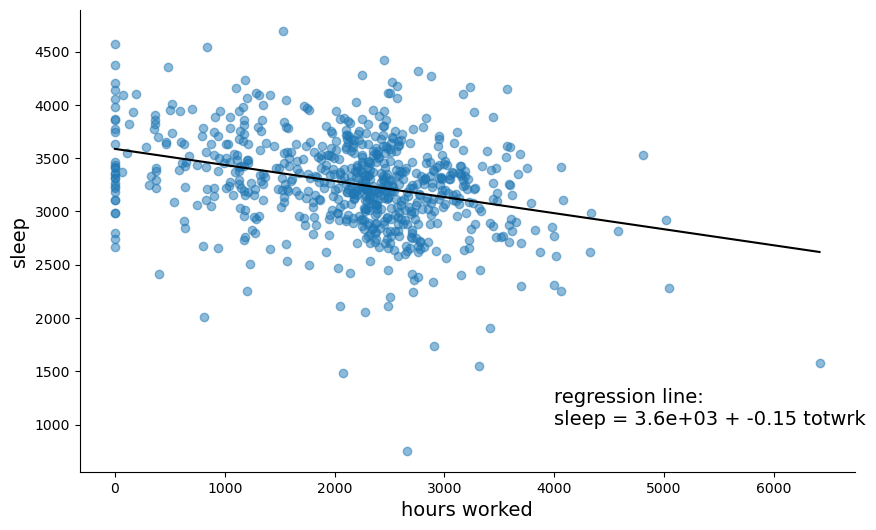

In [29]:
fig, ax = plt.subplots(figsize=(10,6))

# plot the data
ax.scatter(sleep['totwrk'], sleep['sleep'], marker='o', alpha = 0.5 )

# plot the regression line
ax.plot(x,y, color='black')

# build the string and add to plot
text = 'regression line: \nsleep = {0:.2} + {1:.2} totwrk'.format(p.Intercept, p.totwrk)
ax.text(4000, 1000, text, fontsize=14)

ax.set_xlabel('hours worked', fontsize=14)
ax.set_ylabel('sleep', fontsize=14)

sns.despine(ax=ax)

### Plotting confidence intervals

Another benefit of doing this ourselves is that we can plot custom confidence intervals ('HC3', clustered, ...), which can't be done with seaborn. However, coding the confidence intervals takes more practice than simply adding the argument `ci=95` to `sns.regplot()`.

Let's continue with our example above. We'll use a different method to access the confidence intervals. inside our `results2` object, we get predictions in a dataframe called `summary_frame`. Let's extract the confidence intervals around the predicted values (`'mean_ci_upper'` and `'mean_ci_lower'`).

In [30]:
# get predictions from results
predictions = results2.get_prediction()
summary_frame = predictions.summary_frame(alpha=0.05)  # specify 95% confidence level

# extract confidence intervals
ci_lower = summary_frame['mean_ci_lower']
ci_upper = summary_frame['mean_ci_upper']

We can copy the `sns.seaborn` style of confidence intervals by using the `ax.fill_between()` function. \[Note: This is where the data must be sorted by the x-axis. Otherwise, `fill_between()` doesn't work well.\]

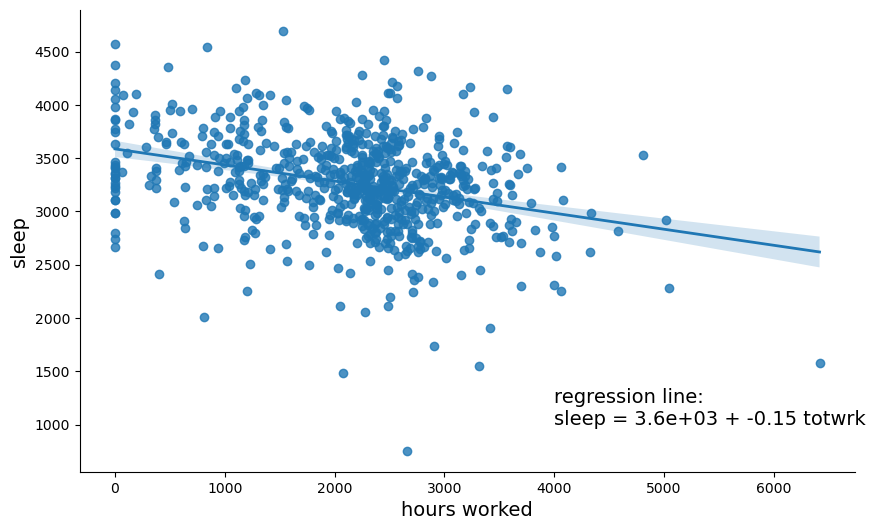

In [31]:
fig, ax = plt.subplots(figsize=(10,6))

# plot the data
ax.scatter(sleep['totwrk'], sleep['sleep'], marker='o', alpha=0.8)

# plot the regression line
ax.plot(x,y, linewidth=2)

# plot the confidence intervals
ax.fill_between(sleep['totwrk'], ci_lower, ci_upper, color='C0', alpha=0.2, edgecolor='none') 

# build the string and add to the plot
text = 'regression line: \nsleep = {0:.2} + {1:.2} totwrk'.format(p.Intercept, p.totwrk)

ax.text(4000, 1000, text, fontsize=14)

ax.set_xlabel('hours worked', fontsize=14)
ax.set_ylabel('sleep', fontsize=14)

sns.despine(ax=ax)

### Compare to seaborn's `sns.regplot()`
We could have simply run the following:

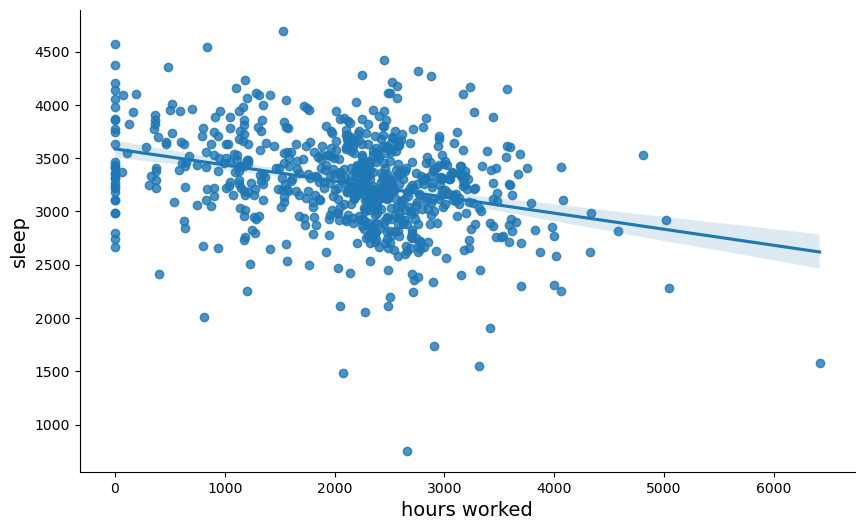

In [32]:
fig, ax = plt.subplots(figsize=(10,6))

sns.regplot(data=sleep, x='totwrk', y='sleep', ci=95)

ax.set_xlabel('hours worked', fontsize=14)
ax.set_ylabel('sleep', fontsize=14)

sns.despine(ax=ax)

But again, the tradeoff is that seaborn has many great visualization features, but very little built-in flexibility for the underlying statistical models. We can't even display the formula for the regression line! Seaborn is not (and apparently never will be) intended for statistical modeling.

## Extra Practice - Try at Home

Read in the 'broadband.xlsx' data from our seaborn lecture and clean up the variable names:

In [33]:
broad = pd.read_excel('broadband_size.xlsx')
broad.columns = ['cty', 'broad_pen', 'gdp_cap', 'pop']

FileNotFoundError: [Errno 2] No such file or directory: 'broadband_size.xlsx'

Recall the following regplot from the seaborn lecture:

In [ ]:
fig, ax = plt.subplots(figsize=(12,7)) 

sns.regplot(x='gdp_cap', y='broad_pen', data=broad,               # the data
            ax = ax,                                              # an axis object
            color = 'blue',                                       # make it blue
            ci = 95,                                              # confidence interval: pass it the percent
            logx = True)                                          # fit the line to y = log(x)

sns.despine(ax = ax)                  

ax.set_title('Broadband penetration and income')
ax.set_ylabel('broadband subscribers per 100 people')
ax.set_xlabel('GDP per capita')

plt.show()

Can you reproduce this figure with statsmodels and matplotlib?

1. Sort the `broad` dataframe on the values of 'gdp_cap'.
2. Estimate the following ordinary least squares regression
```python
broad_pen ~ np.log(gdp_cap)
```
Store the parameter estimates.

3. Use `np.linspace()` ([docs](https://numpy.org/doc/2.1/reference/generated/numpy.linspace.html)) to create an array `x` that spans the range of 'gdp_cap'. \[Why do we need more than two points now?\]
4. Create an array `y` that stores the predicted value for every point in the array `x`.

5. Use the summary_frame method to store the upper and lower bounds of the 95% confidence intervals for each observation.

6. Create a scatter plot of broad_pen (y-axis) vs gdp_cap (x-axis). On your plot, add the fitted line and confidence intervals from the regression. Try to match the style of the regplot figure.
7. Add the formula for the regression line on your figure.

# Causality

The above estimates reflect *associations* between variables, but the goal of econometric analysis is often to estimate the *causal effect* of one variable (the "treatment" variable) on another (the "outcome" variable). 

The **gold standard** for causal inferences is a randomized controlled trial (RCT), wherein some units of observation (the "treated units") are randomly chosen and exposed to treatment, and others (the "control units") are not. RCTs can and do occur in the social sciences, see [here](https://www.socialscienceregistry.org/) for some examples. But there are many barriers to running RCTs to answer certain questions - these barriers could be financial, technical, ethical, etc. Consider the following question: "What is the effect of an additional year of education on earnings?" What are potential barriers to running an RCT to answer this question?

## Observational data

When RCTs are infeasible, the next best option is to answer the question of interest using observational data in which *treatment* varies. 

Let's follow [David Card's](https://davidcard.berkeley.edu/papers/geo_var_schooling.pdf) exploration of the above question using the National Longitudinal Survey (NLS) original cohort of young men. You can obtain the data from Card's website, but a cleaner file is available from Bruce Hansen's [econometrics textbook](https://users.ssc.wisc.edu/~bhansen/econometrics/).

In [ ]:
# Choose the columns of interest
vars=['lwage76', 'ed76', 'age76', 'black', 'reg76r', 'smsa76r',
      'momed', 'daded', 'nomomed', 'nodaded', 'iq', 'nearc4']
wage = pd.read_stata('Card1995.dta',columns=vars)
wage.head()

In [ ]:
wage.dtypes

The types are a bit different from what we're used to. If we leave the integers as type `int8`, we may encounter issues, so we'll convert to our usual integer type `int64`.

In [ ]:
# convert the int types
int_vars = ['nearc4','ed76','age76','black','reg76r','smsa76r','nomomed','nodaded']
for var in int_vars:
    wage[var]=wage[var].astype('int64')
wage.dtypes

We'll follow Card (and many others) by constructing a measure of *potential* labor force experience. This a commonly used estimate of of labor force experience implied by age and education level. Let's also create a separate variable for squared experience.

In [ ]:
# Potential labor force experience and squared term
wage['exp76']=wage['age76']-wage['ed76']-6
wage['exp76sq'] = wage['exp76']**2
wage.head()

## Estimating a Mincer earnings regression

We'll estimate a "Mincer" earnings regression. Here, the (log) hourly wage is regressed on education, a quadratic experience term, and possibly some controls $X_i$ (omitted for now).

$log(wage_i) = \alpha_0+\beta educ_i + \alpha_1 exp_i + \alpha_2 exp_i^2 + \alpha_3 X_i +\epsilon_i$

Ideally, we would like to estimate this specification in such a way that we can interpret the coefficient on education $\beta$ as the (causal) "return to education."

In [ ]:
# basic Mincer regression
res_wageed = smf.ols('lwage76 ~ ed76 + exp76 + exp76sq', data=wage).fit()
print(res_wageed.summary())

*Reasonable interpretation*: A one-year increase in education is associated with approximately a 9.3% higher hourly wage.

*NOT a reasonable interpretation*: A one-year increase in education causes hourly wages to increase by approximately 9.3%.

Major concern: **omitted variable bias**. In the extreme, we could observe a significant positive correlation between education and wages even if the causal effect of education on wages is zero! Are there unobserved factors that cause workers to have a high level of education *and* a high wage? What's in the error term $\epsilon_i$?

To explore one example, let's consider the possibility that individuals with a high IQ may attain higher levels of education, and may also tend to be more productive workers at any level of education.

So, what's the correlation between IQ score and log of wage?

In [ ]:
res_wageiq = smf.ols('lwage76 ~ iq', data=wage).fit()
print(res_wageiq.summary())

What's the correlation between IQ score and education?

In [ ]:
res_ediq = smf.ols('ed76 ~ iq', data=wage).fit()
print(res_ediq.summary())

IQ score is positively correlated with both. This doesn't prove that the correlation between education and wages is not causal, but we certainly need to be careful about making such a claim.

Let's run the Mincer regression again, this time controlling for IQ score. How does it affect the results?

In [ ]:
res_wageed2 = smf.ols('lwage76 ~ ed76 + exp76 + exp76sq + iq', data=wage).fit()
print(res_wageed2.summary())

Reasonable interpretation: Controlling for IQ score, a one-year increase in education is associated with approximately a 7.1% higher hourly wage.

The fact that the coefficient estimate of $\beta$ decreased (from 0.0932 to 0.0706) when `iq` was added is concerning. What if we add even more relevant controls observed in the data? What about relevant factors that we can't observe? Might the estimate of $\beta$ shrink to zero? Such factors are known as *confounders*.

This informal robustness check is sometimes referred to as *coefficient stability*.

## What to do?

In the next few sessions, we'll cover several "identification strategies" or "empirical strategies" for identifying causal effects. These will include:

* Instrumental variables
* Regression discontinuity
* Difference-in-differences